In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('../data/spam_data.csv')
print(df.head())

   label                                               text
0      0  Hi, are we still meeting for coffee at 5 PM to...
1      1  WINNER! You have been selected for a Rs.10000 ...
2      0  Can you please send over the project report by...
3      1  URGENT: Your account has been compromised. Ver...
4      0  The team meeting has been rescheduled to tomor...


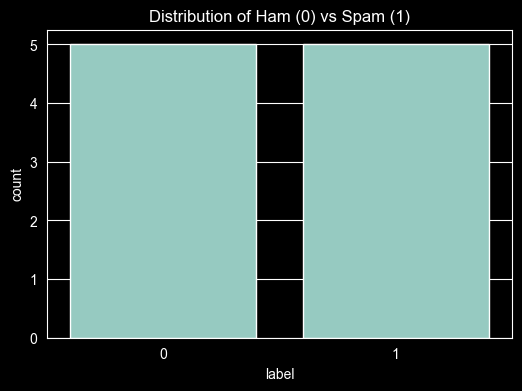

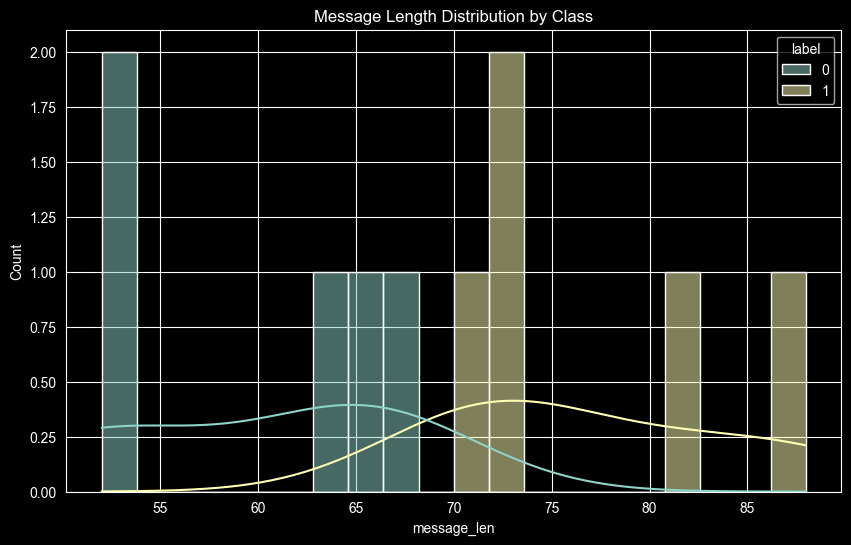

In [2]:
# Check class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Ham (0) vs Spam (1)')
plt.show()

# Add a column for message length
df['message_len'] = df['text'].apply(len)
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='message_len', hue='label', bins=20, kde=True)
plt.title('Message Length Distribution by Class')
plt.show()


In [3]:
# Split data into features and target
X = df['text']
y = df['label']

# Vectorize the text data
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X_tfidf = vectorizer.fit_transform(X)

# Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


In [4]:
# Initialize and train the model
model = MultinomialNB()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


Accuracy: 1.00

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



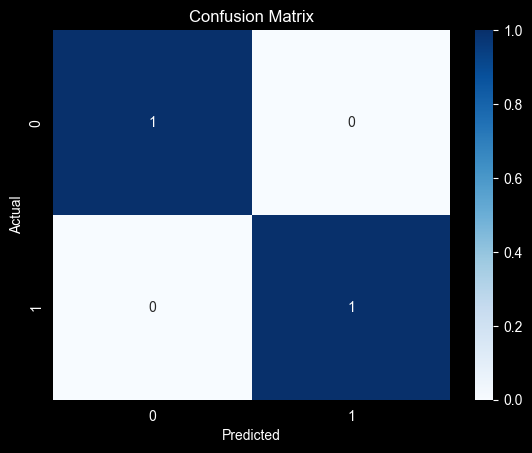

In [5]:
# Print Accuracy and Report
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [6]:
import joblib

# Create models directory if it doesn't exist
import os
if not os.path.exists('../models'):
    os.makedirs('../models')

# Save model and vectorizer
joblib.dump(model, '../models/spam_model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')
print("Model and Vectorizer saved successfully!")


Model and Vectorizer saved successfully!
